# Data Quality Report: invoice_level_sales.csv
**Dataset:** data/input/raw/invoice_level_sales.csv
**Generated:** May 1, 2026
**Rows:** 6,799,893 | **Columns:** 12

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

# ── Load dataset ──────────────────────────────────────────────────
DATASET_PATH = "./../../data/input/raw/invoice_level_sales.csv"

ext = DATASET_PATH.rsplit(".", 1)[-1].lower()
loaders = {"csv": pd.read_csv, "parquet": pd.read_parquet,
           "json": pd.read_json, "xlsx": pd.read_excel, "xls": pd.read_excel}
df = loaders[ext](DATASET_PATH)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 6,799,893 rows × 12 columns


,documentDate,DocumnetNumber,OutletID,TerritoryID,DocumentType,ItemCode,RouteID,PaymentTerm,IsDirectDistributor,NetSales,Quantity,Discount
0,2015-01-01,INV017109010,709293,171,Invoice,PF0084103,UP01027,30 Days,NO,1760.0,4,0.0
1,2015-01-01,INV017109010,709293,171,Invoice,TT0010103,UP01027,30 Days,NO,2350.0,5,0.0
2,2015-01-01,INV017109010,709293,171,Invoice,WF8060101,UP01027,30 Days,NO,630.0,12,0.0
3,2015-01-01,INV024111613,016780,241,Invoice,GF4501101,WP02073,30 Days,NO,3927.0,60,0.0
4,2015-01-01,INV015810027,717003,158,Invoice,GF4501101,SP03020,Cash,NO,804.6,12,0.0


## Step 1 — Dataset Overview
High-level shape, column names, and dtypes.

In [2]:
print(f"Shape: {df.shape}")
print("\nColumn dtypes:")
print(df.dtypes.to_string())

Shape: (6799893, 12)

Column dtypes:
documentDate               str
DocumnetNumber             str
OutletID                object
TerritoryID              int64
DocumentType               str
ItemCode                   str
RouteID                    str
PaymentTerm                str
IsDirectDistributor        str
NetSales               float64
Quantity                 int64
Discount               float64


## Step 2 — Null / Missing Analysis
Percentage of missing values per column.

,Column,Null Count,Null %
7,PaymentTerm,320181,4.710000
0,documentDate,0,0.000000
1,DocumnetNumber,0,0.000000
2,OutletID,0,0.000000
3,TerritoryID,0,0.000000
4,DocumentType,0,0.000000
5,ItemCode,0,0.000000
6,RouteID,0,0.000000
8,IsDirectDistributor,0,0.000000
9,NetSales,0,0.000000


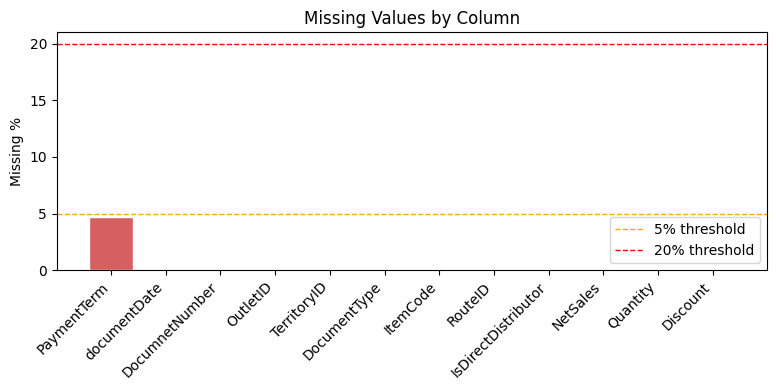

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

null_data = {
    "Column":     ["documentDate", "DocumnetNumber", "OutletID", "TerritoryID", "DocumentType", "ItemCode", "RouteID", "PaymentTerm", "IsDirectDistributor", "NetSales", "Quantity", "Discount"],
    "Null Count": [0, 0, 0, 0, 0, 0, 0, 320181, 0, 0, 0, 0],
    "Null %":     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.71, 0.0, 0.0, 0.0, 0.0],
}
null_df = pd.DataFrame(null_data).sort_values("Null %", ascending=False)
display(null_df.style.bar(subset=["Null %"], color="#d65f5f", vmin=0, vmax=100))

# Bar chart
fig, ax = plt.subplots(figsize=(max(8, len(null_df)*0.5), 4))
ax.bar(null_df["Column"], null_df["Null %"], color="#d65f5f", edgecolor="white")
ax.axhline(5,  color="orange", linestyle="--", linewidth=1, label="5% threshold")
ax.axhline(20, color="red",    linestyle="--", linewidth=1, label="20% threshold")
ax.set_ylabel("Missing %")
ax.set_title("Missing Values by Column")
ax.set_xticklabels(null_df["Column"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Numeric Statistics
Descriptive statistics for all numeric columns.

In [4]:
df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
TerritoryID,6799893.000000,111.588996,81.524046,2.000000,40.000000,97.000000,174.000000,441.000000
NetSales,6799893.000000,1835.391276,15923.393759,-2439386.250000,265.440000,481.800000,1056.000000,6292000.000000
Quantity,6799893.000000,51.995388,442.973984,0.000000,6.000000,12.000000,30.000000,200000.000000
Discount,6799893.000000,77.349642,1573.091983,-109534.480000,0.000000,0.000000,0.000000,858000.000000


## Step 4 — Categorical Distributions
Value counts for low-cardinality (≤ 50 unique values) columns.

In [14]:
# Filter the dataset for DocumentType == 'Return' and describe
df_return = df[df['DocumentType'] == 'Return']
df_return.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
TerritoryID,281542.000000,114.441749,79.638215,2.000000,44.000000,104.000000,173.000000,441.000000
NetSales,281542.000000,-6143.568506,23585.332340,-2439386.250000,-4590.000000,-1243.200000,-448.800000,0.000000
Quantity,281542.000000,121.356846,583.946617,0.000000,8.000000,24.000000,60.000000,75000.000000
Discount,281542.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


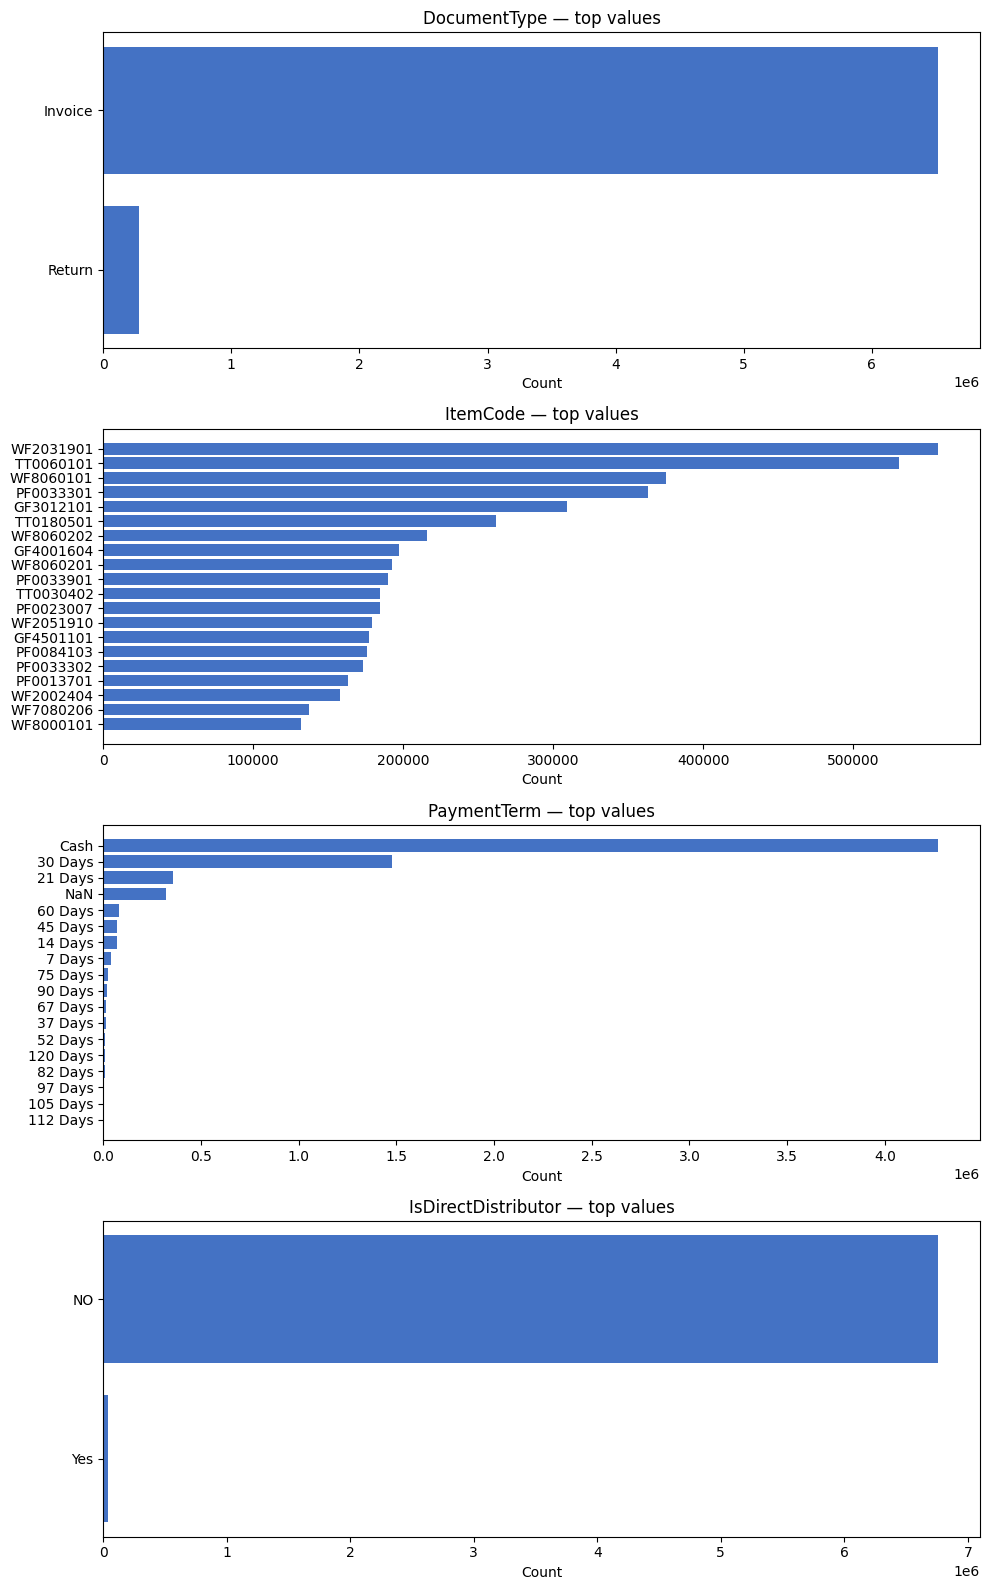

In [10]:
cat_cols = [c for c in df.columns if df[c].nunique() <= 50 and not pd.api.types.is_numeric_dtype(df[c])]

if not cat_cols:
    print("No categorical columns found.")
else:
    fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))
    if len(cat_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols):
        vc = df[col].fillna('NaN').astype(str).value_counts().head(20)
        ax.barh(vc.index, vc.values, color="#4472C4")
        ax.set_title(f"{col} — top values")
        ax.set_xlabel("Count")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Step 5 — Data Quality Issue Detection
Automated checks for nulls, outliers, skew, cardinality, and imbalance.

In [11]:
import pandas as pd

issues_data = [
    {"Column": "PaymentTerm", "Issue": "Moderate nulls", "Detail": "4.71% missing", "Severity": "Medium", "Remedy": "Impute with median/mean (numeric) or most-frequent (categorical). Flag non-random nulls for review."},
    {"Column": "DocumentType", "Issue": "Imbalanced categorical", "Detail": "Invoice is 95.9% of values", "Severity": "Medium", "Remedy": "Use SMOTE, class-weighted models, or stratified splits. Confirm bias vs. reality."},
    {"Column": "IsDirectDistributor", "Issue": "Imbalanced categorical", "Detail": "NO is 99.4% of values", "Severity": "Medium", "Remedy": "Use SMOTE, class-weighted models, or stratified splits. Confirm bias vs. reality."},
    {"Column": "NetSales", "Issue": "Potential outliers", "Detail": "Values beyond 3*IQR from quartiles", "Severity": "Medium", "Remedy": "Clip to [p1, p99] or apply IQR capping. Confirm whether values are errors or legitimate."},
    {"Column": "NetSales", "Issue": "High right skew", "Detail": "mean/median = 3.81", "Severity": "Low", "Remedy": "Apply log / sqrt / Box-Cox transform before algorithms that assume normality."},
    {"Column": "Quantity", "Issue": "Potential outliers", "Detail": "Values beyond 3*IQR from quartiles", "Severity": "Medium", "Remedy": "Clip to [p1, p99] or apply IQR capping. Confirm whether values are errors or legitimate."},
    {"Column": "Quantity", "Issue": "High right skew", "Detail": "mean/median = 4.33", "Severity": "Low", "Remedy": "Apply log / sqrt / Box-Cox transform before algorithms that assume normality."},
]

if not issues_data:
    print("✅ No data quality issues detected.")
else:
    issues_df = pd.DataFrame(issues_data)
    severity_order = {"High": 0, "Medium": 1, "Low": 2}
    issues_df["_order"] = issues_df["Severity"].map(severity_order)
    issues_df = issues_df.sort_values("_order").drop(columns=["_order"])

    def color_severity(val):
        colors = {"High": "background-color: #f4cccc",
                  "Medium": "background-color: #fff2cc",
                  "Low": "background-color: #cfe2f3"}
        return colors.get(val, "")

    display(issues_df.style.map(color_severity, subset=["Severity"]))

,Column,Issue,Detail,Severity,Remedy
0,PaymentTerm,Moderate nulls,4.71% missing,Medium,Impute with median/mean (numeric) or most-frequent (categorical). Flag non-random nulls for review.
1,DocumentType,Imbalanced categorical,Invoice is 95.9% of values,Medium,"Use SMOTE, class-weighted models, or stratified splits. Confirm bias vs. reality."
2,IsDirectDistributor,Imbalanced categorical,NO is 99.4% of values,Medium,"Use SMOTE, class-weighted models, or stratified splits. Confirm bias vs. reality."
3,NetSales,Potential outliers,Values beyond 3*IQR from quartiles,Medium,"Clip to [p1, p99] or apply IQR capping. Confirm whether values are errors or legitimate."
5,Quantity,Potential outliers,Values beyond 3*IQR from quartiles,Medium,"Clip to [p1, p99] or apply IQR capping. Confirm whether values are errors or legitimate."
4,NetSales,High right skew,mean/median = 3.81,Low,Apply log / sqrt / Box-Cox transform before algorithms that assume normality.
6,Quantity,High right skew,mean/median = 4.33,Low,Apply log / sqrt / Box-Cox transform before algorithms that assume normality.


## Step 6 — Remedial Actions
Recommended fixes for each detected issue.

In [12]:
remedies_data = [
    {"Column": "PaymentTerm", "Issue": "Moderate nulls", "Severity": "Medium", "Recommended Action": "Impute with most-frequent term or investigate missing payment terms in the source pipeline."},
    {"Column": "DocumentType", "Issue": "Imbalanced categorical", "Severity": "Medium", "Recommended Action": "Use class weights or stratified sampling; confirm whether Invoice/Return share the same production distribution."},
    {"Column": "IsDirectDistributor", "Issue": "Imbalanced categorical", "Severity": "Medium", "Recommended Action": "Review whether direct distributor labeling is complete and consider grouping for modeling."},
    {"Column": "NetSales", "Issue": "Potential outliers", "Severity": "Medium", "Recommended Action": "Verify extreme sales values, then cap or transform if they are data entry or invoice aggregation artifacts."},
    {"Column": "NetSales", "Issue": "High right skew", "Severity": "Low", "Recommended Action": "Apply log or power transform before algorithms that assume normality."},
    {"Column": "Quantity", "Issue": "Potential outliers", "Severity": "Medium", "Recommended Action": "Inspect extreme quantities and cap at a business-relevant maximum if needed."},
    {"Column": "Quantity", "Issue": "High right skew", "Severity": "Low", "Recommended Action": "Consider log or Box-Cox scaling for modeling."},
]

if not remedies_data:
    print("✅ No remedial actions required.")
else:
    pd.DataFrame(remedies_data).style.map(color_severity, subset=["Severity"])

In [13]:
remedies_data

[{'Column': 'PaymentTerm',
  'Issue': 'Moderate nulls',
  'Severity': 'Medium',
  'Recommended Action': 'Impute with most-frequent term or investigate missing payment terms in the source pipeline.'},
 {'Column': 'DocumentType',
  'Issue': 'Imbalanced categorical',
  'Severity': 'Medium',
  'Recommended Action': 'Use class weights or stratified sampling; confirm whether Invoice/Return share the same production distribution.'},
 {'Column': 'IsDirectDistributor',
  'Issue': 'Imbalanced categorical',
  'Severity': 'Medium',
  'Recommended Action': 'Review whether direct distributor labeling is complete and consider grouping for modeling.'},
 {'Column': 'NetSales',
  'Issue': 'Potential outliers',
  'Severity': 'Medium',
  'Recommended Action': 'Verify extreme sales values, then cap or transform if they are data entry or invoice aggregation artifacts.'},
 {'Column': 'NetSales',
  'Issue': 'High right skew',
  'Severity': 'Low',
  'Recommended Action': 'Apply log or power transform before al

## Conclusion

### Dataset Summary
| Metric | Value |
|--------|-------|
| Total rows | 6,799,893 |
| Total columns | 12 |
| Columns with >5% nulls | 1 |
| Columns with >20% nulls | 0 |
| Numeric columns | 4 |
| Categorical columns | 8 |
| Total DQ issues found | 5 |

### Issue Breakdown
| Severity | Count |
|----------|-------|
| 🔴 High | 0 |
| 🟡 Medium | 5 |
| 🔵 Low | 2 |

### Key Findings
- `PaymentTerm` has 4.71% missing values, making it a moderate data-quality concern.
- `DocumentType` is heavily skewed toward `Invoice` (95.9%), and `IsDirectDistributor` is dominated by `NO` (99.4%).
- `NetSales` and `Quantity` both show strong right skew and outlier risk, indicating non-normal distributions and extreme transaction values.
- No columns are fully null or single-value, so completeness is good overall.

### Recommended Next Steps
1. Impute or review missing `PaymentTerm` entries, since they represent a non-trivial share of invoices.
2. Confirm whether `DocumentType` and `IsDirectDistributor` distributions are expected business behavior before modeling.
3. Investigate extreme `NetSales` and `Quantity` records to determine whether they are legitimate large orders or data errors.
4. Apply log/power transforms for skewed numeric features if using models sensitive to distribution shape.
5. Exclude high-cardinality IDs such as `DocumnetNumber` and `OutletID` from modeling features unless specifically required for joins or tracking.